# Single Particle Tracking simulator

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import skimage
import random
import stackview
import cv2

In [2]:
from helpers import *

## 1. Particles generation

Goal: create a generator of N particles at random positions in (0, 128) (not too close to edges) with diffusion coefficient in (0,4)

In [3]:
N =10
particles = generate_particles_OOP(N) # a list of Particle objects
print(len(particles))

10


### Image generation

In [4]:
img = uniform_bg(128, value=100)
#show_img(img)

### Place particles one by one and apply Gaussian blur

Particle 1 at (123.70424629509029, 61.963370932045336) with diffusion coefficient 3
Particle 2 at (109.23741213917953, 78.04353989329117) with diffusion coefficient 0
Particle 3 at (103.1735251910276, 70.6508141340288) with diffusion coefficient 1
Particle 4 at (82.1289856523785, 26.345794428079017) with diffusion coefficient 2
Particle 5 at (55.80136397267144, 32.376147420815414) with diffusion coefficient 0
Particle 6 at (48.77198844839076, 10.651436690958093) with diffusion coefficient 3
Particle 7 at (55.5716868470944, 79.81300609338284) with diffusion coefficient 4
Particle 8 at (74.8459113163515, 119.71650729844909) with diffusion coefficient 2
Particle 9 at (82.72322016396413, 97.44803407066) with diffusion coefficient 4
Particle 10 at (2.066470019536652, 92.28050354284134) with diffusion coefficient 1


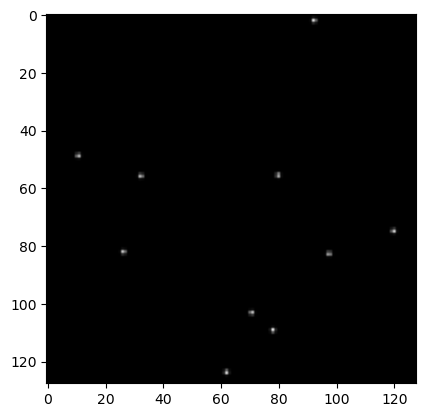

In [5]:
img = place_particles_OOP(img, particles, c = 65535, sigma = 0.5)
show_img(img)

In [6]:
# check min and max of image
check_min_max(img)

min: 100
max: 58426


=> no point is at exactly the max because of reel center coordinates 

## 2. Frames generation

Update following normal diffusion (Brownian motion)

In [7]:
F = 30
# trajectories_GT represent the TRUE trajectories of each particle
frames, trajectories_GT = generate_frames_OOP(F, N) 

Frame 1
Particle 1 at (37.85056504587871, 106.94281026029249) with diffusion coefficient 0
Particle 2 at (124.8156813898194, 63.45454242242302) with diffusion coefficient 1
Particle 3 at (83.73465488046736, 38.75583315210157) with diffusion coefficient 3
Particle 4 at (17.680645532823718, 91.94892202806822) with diffusion coefficient 0
Particle 5 at (35.420510084156234, 41.38539308394445) with diffusion coefficient 4
Particle 6 at (33.68662316732794, 123.80519922250801) with diffusion coefficient 3
Particle 7 at (102.34549475406232, 76.87598020238603) with diffusion coefficient 3
Particle 8 at (51.24743928367431, 50.5642855853508) with diffusion coefficient 1
Particle 9 at (65.32758144699295, 30.281024279939004) with diffusion coefficient 0
Particle 10 at (19.883138094555164, 40.77995893188414) with diffusion coefficient 0
Frame 2
Particle 1 at (37.85056504587871, 106.94281026029249) with diffusion coefficient 0
Particle 2 at (125.4394205758188, 62.672909882255446) with diffusion coeff

Visualization: stackview

In [8]:
# visualize the frames with stackview
stack = np.stack(frames, axis=0).astype(np.float32)
stack = np.clip(stack, 0, 65535)

stackview.slice(stack, continuous_update=True)

In [9]:
print(trajectories_GT[0].length())
trajectories_GT[0].print_trajectory()

30
Trajectory for Particle 1:
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float64(37.85056504587871), np.float64(106.94281026029249))
(np.float6

## 3. MSD Extraction

### 3.1 D_estimate (?)

In [10]:
msd = msd_trajectories(trajectories_GT)

C:\Users\armel\AppData\Local\Temp\ipykernel_4248\1595166062.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


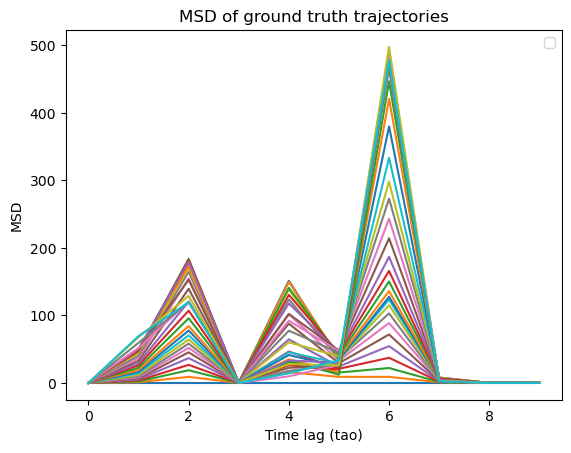

In [11]:
# plot ground truth MSD
plt.figure()
plt.plot(msd)
plt.xlabel('Time lag (tao)')
plt.ylabel('MSD')
plt.title('MSD of ground truth trajectories')
plt.legend()

In [12]:
D_GT = []
for i in range(len(msd)):
    D_estimated = estimateDfromMSD(msd[i], np.arange(len(msd[i])))
    D_GT.append(D_estimated)
print(f"Estimated D: {D_GT}")


Estimated D: [np.float64(-0.0), np.float64(0.5487532624586839), np.float64(1.727040903138952), np.float64(-0.0), np.float64(0.7445171801684913), np.float64(0.3908163732587478), np.float64(4.396336860414126), np.float64(0.06656711109664108), np.float64(-0.0), np.float64(-0.0)]


In [13]:
D_true = []
for i in range(N):
    D_true.append(particles[i].d)
    
print('True D:', D_true)

True D: [3, 0, 1, 2, 0, 3, 4, 2, 4, 1]


In [14]:
print('Absolute error in D estimation:', np.abs(np.array(D_true) - np.array(D_GT)))

Absolute error in D estimation: [3.         0.54875326 0.7270409  2.         0.74451718 2.60918363
 0.39633686 1.93343289 4.         1.        ]


### 3.2 D_localizsation

Simple Nearest Neighbor tracking

In [15]:
from skimage.feature import peak_local_max

In [16]:
# implement peak finder on each frame to extract particles trajectories
detected_peaks = []
for frame in frames:
    peaks = peak_local_max(frame, min_distance=1, threshold_abs=20000)
    detected_peaks.append(peaks)

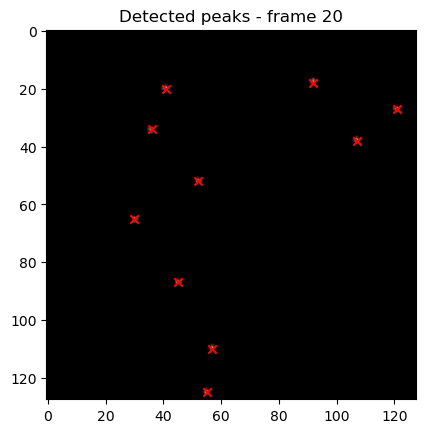

In [17]:
# visualize quality of peak detection
i = 19
plt.imshow(frames[i], cmap='gray')
plt.scatter(detected_peaks[i][:, 1], detected_peaks[i][:, 0], c='r', marker='x')
plt.title(f'Detected peaks - frame {i+1}')
plt.show()

In [18]:
trajectories = NN_tracking(detected_peaks, max_distance=5)

print("Number of trajectories:", len(trajectories))
for traj in trajectories:
    print(traj.id, traj.get_positions())

print("Sizes of trajectories:", [len(traj.get_positions()) for traj in trajectories])

Number of trajectories: 10
0 [(np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107)), (np.int64(38), np.int64(107))]
1 [(np.int64(20), np.int64(41)), (np.int

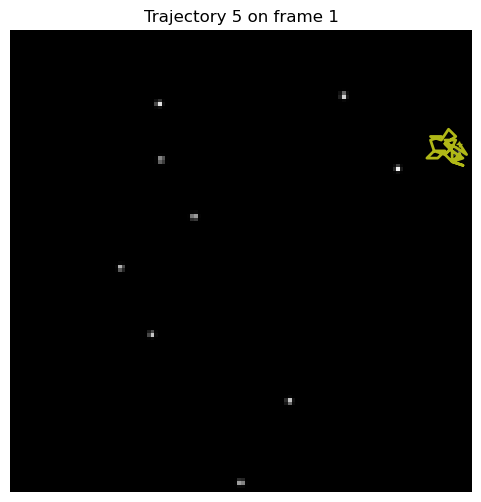

In [20]:
show_trajectory(frames, trajectories, traj_id=5)

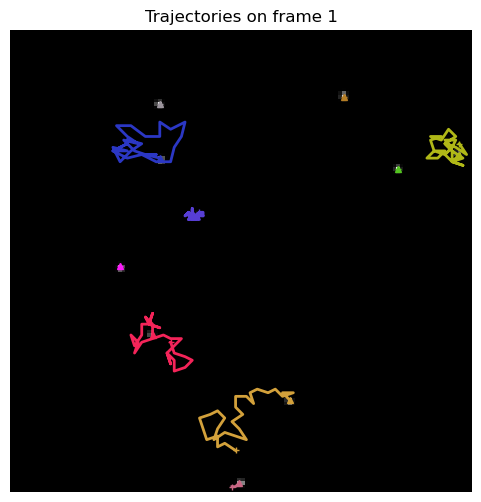

In [21]:
show_trajectories(frames, trajectories, frame_id=0)

## D_localization estimation

In [22]:
msd_localization = msd_trajectories(trajectories)

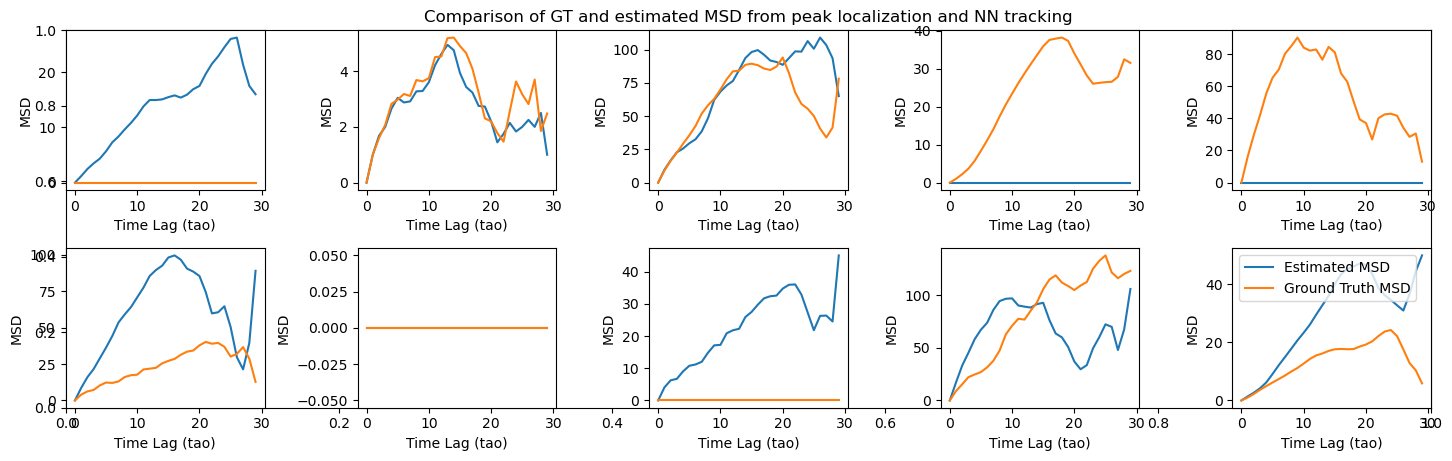

In [23]:
# plot the MSD
plt.figure(figsize=(15, 5))
plt.title(f'Comparison of GT and estimated MSD from peak localization and NN tracking')
for i in range(len(msd_localization)):
    plt.subplot(2, len(msd_localization)//2 + len(msd_localization) % 2, i+1)
    plt.plot(msd_localization[i], label='Estimated MSD')
    plt.plot(msd[i], label='Ground Truth MSD')
    plt.xlabel('Time Lag (tao)')
    plt.ylabel('MSD')
plt.legend()
plt.tight_layout()

In [24]:
D_localization = []
for i in range(len(msd_localization)):
    D_estimated = estimateDfromMSD(msd_localization[i], np.arange(len(msd_localization[i])))
    D_localization.append(D_estimated)
print(f"Estimated D: {D_localization}")

Estimated D: [np.float64(0.22684442408270755), np.float64(0.03318728652003841), np.float64(1.111127149315671), np.float64(-0.0), np.float64(-0.0), np.float64(0.8469091978696762), np.float64(-0.0), np.float64(0.35277176338766947), np.float64(0.8548145132592425), np.float64(0.4641480041387774)]


In [25]:
print('Absolute error in D GT vs. by localization:', np.abs(np.array(D_true) - np.array(D_GT)))

Absolute error in D GT vs. by localization: [1.         2.95980047 0.15922585 0.63202386 1.37746996 1.63301618
 3.         2.         2.66112935 2.79406234]
